In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import wesanderson
from scipy.stats import weibull_min, gamma, probplot, linregress,t
from scipy.optimize import minimize
import scipy.special
import csv
import os
import sys
import matplotlib.pylab as pl
from pathlib import Path

SCRIPTS_DIR = Path("../scripts")
rawDATA_DIR = Path("../data/raw")
processedDATA_DIR = Path("../data/processed")
FIG_DIR = Path("../figs")

rawDATA_DIR.mkdir(parents=True, exist_ok=True)
processedDATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(os.path.abspath("../scripts"))
from utils import fit_gamma, fit_all_weibulls

from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "font.size" : 15,
    "figure.titlesize": 15,
    "pgf.rcfonts": False    
})

# %matplotlib inline

# Plotting Weibull and Gamma distributions

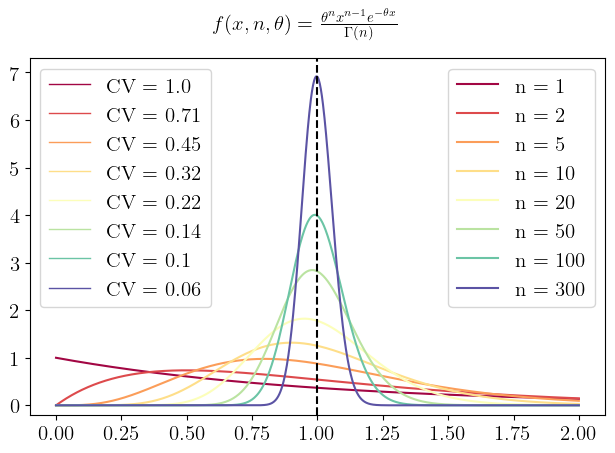

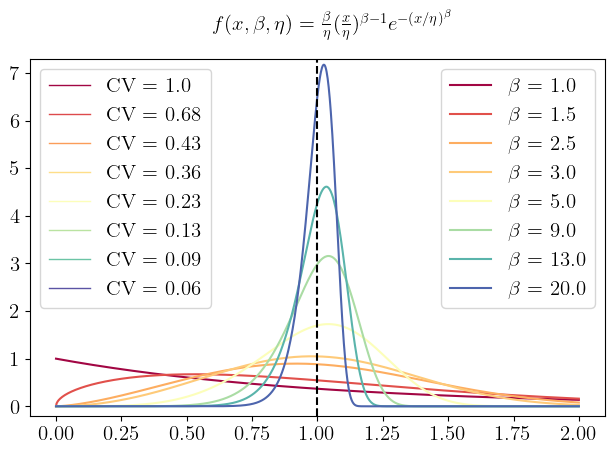

In [18]:
n_colors = 100
colors = sns.color_palette("Spectral", n_colors)

x = np.linspace(0,2,1000)

log_cv_max = np.log(gamma.std(a = 300, scale = 1/300, loc = 0))

fig = plt.figure()
gamma_shapes = np.array([1,2,5,10,20,50,100,300])
color_list = []
cv_list = []
for i,shape in enumerate(gamma_shapes):
    y = gamma.pdf(x, a = shape, scale = 1/shape, loc = 0)  
    
    cv = gamma.std(a = shape, scale = 1/shape, loc = 0) # Note how scale is set so that mean is 1
    log_cv = np.log(cv)
    norm_cv = log_cv / log_cv_max  # Normalized to [0;1]
    color_idx = int(norm_cv * (n_colors - 1))
    cv_list.append(cv)
    line_color = colors[color_idx]
    color_list.append(line_color)

    
    plt.plot(x,y, color = line_color,  label = "n = " + str(gamma_shapes[i]))
plt.vlines(1, ymin = -0.2, ymax = 7.3, linestyle = "dashed", color = "black")
plt.ylim(-0.2,7.3)
first_legend = plt.legend()

fig.add_artist(first_legend)
legend_elements = [matplotlib.lines.Line2D([0], [0], color=color_list[i], lw=1, label="CV = "+ str(np.round(cv_list[i],2))) for i in range(gamma_shapes.shape[0])]
plt.legend(handles=legend_elements, loc='upper left')

plt.text(0.6, 7.9, r"$f(x, n, \theta) = \frac{\theta^{n} x^{n -1} e^{-\theta x}}{\Gamma(n)}$") 

plt.tight_layout()
plt.savefig(FIG_DIR / "gamma_distribution.pdf")
plt.show()
plt.close()


fig = plt.figure()
weibull_shapes = np.array([1,1.5,2.5,3,5,9,13,20])
cv_list = []
for i,shape in enumerate(weibull_shapes):
    y = weibull_min.pdf(x, c = shape, scale = 1/scipy.special.gamma(1+1/shape), loc = 0) # Note how scale is set so that mean is 1
    
    cv = weibull_min.std(c = shape, scale = 1/scipy.special.gamma(1+1/shape), loc = 0)
    cv_list.append(cv)
    log_cv = np.log(cv)
    norm_cv = log_cv / log_cv_max  # Normalized to [0;1]
    color_idx = int(norm_cv * (n_colors - 1))
    line_color = colors[color_idx]
 
    plt.plot(x,y, color = line_color, label = r"$\beta$" + " = " + str(np.round(weibull_shapes[i],2)))
plt.vlines(1, ymin = -0.2, ymax = 7.3, linestyle = "dashed", color = "black")
plt.ylim(-0.2,7.3)
first_legend = plt.legend()

fig.add_artist(first_legend)
legend_elements = [matplotlib.lines.Line2D([0], [0], color=color_list[i], lw=1, label="CV = "+ str(np.round(cv_list[i],2))) for i in range(weibull_shapes.shape[0])]
plt.legend(handles=legend_elements, loc='upper left')

plt.text(0.6, 7.9, r"$f(x, \beta, \eta) = \frac{\beta}{\eta} (\frac{x}{\eta})^{\beta - 1} e^{-(x/\eta)^{\beta}}$")
plt.tight_layout()
plt.savefig(FIG_DIR / "weibull_distribution.pdf")
plt.show()
plt.close()

# A first test with two examples

In [2]:
weibull_par = np.array([0.2625,3.232,0.7581])
gamma_pars_copy_temp, dist = fit_gamma(weibull_par = weibull_par,
              tau_forced = "copy",
              save = True,
              info = "test1",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_copy",                           
              seed = 0) 
gamma_pars_zero_temp, dist = fit_gamma(weibull_par = weibull_par,
              tau_forced = "zero",
              save = True,
              info = "test1",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_zero",                           
              seed = 0)
gamma_pars_unconstrained_temp, dist = fit_gamma(weibull_par = weibull_par,
              tau_forced = "positive",
              save = True,
              info = "test1",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_positive",                           
              seed = 0) 

weibull_par2 = np.array([1.738,2.610,-0.517])
gamma_pars_copy_temp,dist = fit_gamma(weibull_par = weibull_par2,
              tau_forced = "copy",
              save = True,
              info = "test2",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_copy",                           
              seed = 0) 
gamma_pars_zero_temp,dist = fit_gamma(weibull_par = weibull_par2,
              tau_forced = "zero",
              save = True,
              info = "test2",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_zero",                           
              seed = 0)
gamma_pars_unconstrained_temp,dist = fit_gamma(weibull_par = weibull_par2,
              tau_forced = "positive",
              save = True,
              info = "test2",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_positive",                           
              seed = 0) 


weibull_par3 = np.array([0.9654,35.1806,0.])
gamma_pars_copy_temp,dist = fit_gamma(weibull_par = weibull_par3,
              tau_forced = "copy",
              save = True,
              info = "test3",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_copy",                           
              seed = 0) 
gamma_pars_zero_temp,dist = fit_gamma(weibull_par = weibull_par3,
              tau_forced = "zero",
              save = True,
              info = "test3",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_zero",                           
              seed = 0)
gamma_pars_unconstrained_temp,dist = fit_gamma(weibull_par = weibull_par3,
              tau_forced = "positive",
              save = True,
              info = "test3",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_positive",                           
              seed = 0) 

# Fits multiples et répartition des paramètres shape obtenus : données Egg-Larva-Pupa (ou prePupa)

## Génération des fichiers de fit et de visualisation

In [2]:
gamma_pars_per_stage_zero, gamma_pars_per_stage_pos, gamma_pars_per_stage_copy = fit_all_weibulls(
    input_csv = "Survey_staged",
    output = "gamma_fit_per_stage",
    raw_data_dir = rawDATA_DIR ,
    processed_data_dir = processedDATA_DIR,
    fig_dir = FIG_DIR,
    type_of_stage = "per_stage",
    seed = 0)

Beginning non shifted analysis
(0, 62)
(1, 62)
(2, 62)
(3, 62)
(4, 62)
(5, 62)
(6, 62)
(7, 62)
(8, 62)
(9, 62)
(10, 62)
(11, 62)
(12, 62)
(13, 62)
(14, 62)
(15, 62)
(16, 62)
(17, 62)
(18, 62)
(19, 62)
(20, 62)
(21, 62)
(22, 62)
(23, 62)
(24, 62)
(25, 62)
(26, 62)
(27, 62)
(28, 62)
(29, 62)
(30, 62)
(31, 62)
(32, 62)
(33, 62)
(34, 62)
(35, 62)
(36, 62)
(37, 62)
(38, 62)
(39, 62)
(40, 62)
(41, 62)
(42, 62)
(43, 62)
(44, 62)
(45, 62)
(46, 62)
(47, 62)
(48, 62)
(49, 62)
(50, 62)
(51, 62)
(52, 62)
(53, 62)
(54, 62)
(55, 62)
(56, 62)
(57, 62)
(58, 62)
(59, 62)
(60, 62)
(61, 62)
Beginning positive shift analysis
(0, 62)
(1, 62)
(2, 62)
(3, 62)
(4, 62)
(5, 62)
(6, 62)
(7, 62)
(8, 62)
(9, 62)
(10, 62)
(11, 62)
(12, 62)
(13, 62)
(14, 62)
(15, 62)
(16, 62)
(17, 62)
(18, 62)
(19, 62)
(20, 62)
(21, 62)
(22, 62)
(23, 62)
(24, 62)
(25, 62)
(26, 62)
(27, 62)
(28, 62)
(29, 62)
(30, 62)
(31, 62)
(32, 62)
(33, 62)
(34, 62)
(35, 62)
(36, 62)
(37, 62)
(38, 62)
(39, 62)
(40, 62)
(41, 62)
(42, 62)
(43, 62)
(

## Visualisation des résultats - Histogrammes

In [3]:
%matplotlib inline

### Gamma parameters

In [3]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

total_count = gamma_pars_per_stage_zero.shape[0]

print("Mean shape:")
print(np.mean(gamma_pars_per_stage_zero[:,1]))
print(np.mean(gamma_pars_per_stage_pos[:,1]))
print(np.mean(gamma_pars_per_stage_copy[:,1]))

print("Median shape:")
print(np.median(gamma_pars_per_stage_zero[:,1]))
print(np.median(gamma_pars_per_stage_pos[:,1]))
print(np.median(gamma_pars_per_stage_copy[:,1]))

print("Mean shift:")
print(np.mean(gamma_pars_per_stage_zero[:,2]))
print(np.mean(gamma_pars_per_stage_pos[:,2]))
print(np.mean(gamma_pars_per_stage_copy[:,2]))

print("Max shape:")
print(np.max(gamma_pars_per_stage_zero[:,1]))
print(np.max(gamma_pars_per_stage_pos[:,1]))
print(np.max(gamma_pars_per_stage_copy[:,1]))

print("Min shape:")
print(np.min(gamma_pars_per_stage_zero[:,1]))
print(np.min(gamma_pars_per_stage_pos[:,1]))
print(np.min(gamma_pars_per_stage_copy[:,1]))

print("Count of low shape (<=20):")
print(np.sum(gamma_pars_per_stage_zero[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_zero[:,1] <= 20)/total_count)

print(np.sum(gamma_pars_per_stage_pos[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_pos[:,1] <= 20)/total_count)

print(np.sum(gamma_pars_per_stage_copy[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_copy[:,1] <= 20)/total_count)


print("Significant shape change between zero shift and positive shift:")
significant_change_count = np.where(gamma_pars_per_stage_zero[:,1] - gamma_pars_per_stage_pos[:,1] > 1)[0].shape[0]
print(significant_change_count)
print(significant_change_count/total_count)

Mean shape:
113.54774310915319
88.41231336441213
42.37020004296034
Median shape:
51.590686238407564
26.341100520913642
6.049642761612207
Mean shift:
0.0
0.17835932316490202
0.3790238706935798
Max shape:
782.2167335916554
782.2178347450695
756.7854829328576
Min shape:
0.8711016660727497
0.8712061742817405
1.7655430771213778
Count of low shape (<=20):
16
0.25806451612903225
29
0.46774193548387094
43
0.6935483870967742
Significant shape change between zero shift and positive shift:
20
0.3225806451612903


Removing the cases where weibull shift is negative:

In [13]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

mask = (gamma_pars_per_stage_copy[:,2] > -1e-3) & (gamma_pars_per_stage_copy[:,2] <= 1) # Rempving negative shift outliers
gamma_pars_per_stage_zero = gamma_pars_per_stage_zero[mask]
gamma_pars_per_stage_pos = gamma_pars_per_stage_pos[mask]
gamma_pars_per_stage_copy = gamma_pars_per_stage_copy[mask]

total_count = gamma_pars_per_stage_zero.shape[0]

print("Mean shape:")
print(np.mean(gamma_pars_per_stage_zero[:,1]))
print(np.mean(gamma_pars_per_stage_pos[:,1]))
print(np.mean(gamma_pars_per_stage_copy[:,1]))

print("Median shape:")
print(np.median(gamma_pars_per_stage_zero[:,1]))
print(np.median(gamma_pars_per_stage_pos[:,1]))
print(np.median(gamma_pars_per_stage_copy[:,1]))

print("Mean shift:")
print(np.mean(gamma_pars_per_stage_zero[:,2]))
print(np.mean(gamma_pars_per_stage_pos[:,2]))
print(np.mean(gamma_pars_per_stage_copy[:,2]))

print("Max shape:")
print(np.max(gamma_pars_per_stage_zero[:,1]))
print(np.max(gamma_pars_per_stage_pos[:,1]))
print(np.max(gamma_pars_per_stage_copy[:,1]))

print("Min shape:")
print(np.min(gamma_pars_per_stage_zero[:,1]))
print(np.min(gamma_pars_per_stage_pos[:,1]))
print(np.min(gamma_pars_per_stage_copy[:,1]))

print("Count of low shape (<=20):")
print(np.sum(gamma_pars_per_stage_zero[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_zero[:,1] <= 20)/total_count)

print(np.sum(gamma_pars_per_stage_pos[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_pos[:,1] <= 20)/total_count)

print(np.sum(gamma_pars_per_stage_copy[:,1] <= 20))
print(np.sum(gamma_pars_per_stage_copy[:,1] <= 20)/total_count)


print("Significant shape change between zero shift and positive shift:")
significant_change_count = np.where(gamma_pars_per_stage_zero[:,1] - gamma_pars_per_stage_pos[:,1] > 1)[0].shape[0]
print(significant_change_count)
print(significant_change_count/total_count)

Mean shape:
123.32047670652915
95.98018421562388
45.54444996446453
Median shape:
57.85297233480837
31.276578153131243
6.215013925755231
Mean shift:
0.0
0.1940048778284899
0.4363803512563831
Max shape:
782.2167335916554
782.2178347450695
756.7854829328576
Min shape:
4.477240962756284
1.8605337232301253
1.7655430771213778
Count of low shape (<=20):
11
0.19298245614035087
24
0.42105263157894735
38
0.6666666666666666
Significant shape change between zero shift and positive shift:
20
0.3508771929824561


## Visualisation des résultats - Violinplot et effet du forçage $\tau = 0$

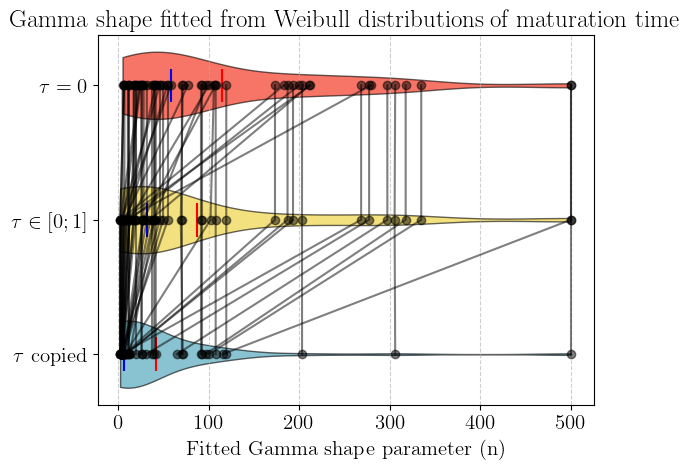

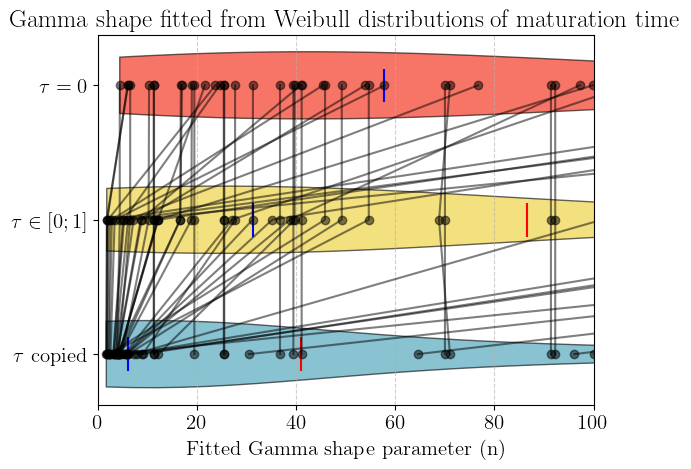

In [15]:
data0 = np.clip(gamma_pars_per_stage_copy[:,1], 0, 500)
data1 = np.clip(gamma_pars_per_stage_pos[:,1], 0, 500)
data2 = np.clip(gamma_pars_per_stage_zero[:,1], 0, 500)
data = [data0, data1, data2]

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

fig, ax = plt.subplots()
box = plt.violinplot(data, vert=False, positions=[1, 2, 3], widths=0.5, showmeans=True, showmedians=True, showextrema=False)

# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('blue')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data1[i], data2[i]], [1, 2, 3],color='black', alpha=0.5, marker='o')
    
# Aesthetic settings
plt.yticks([1, 2, 3])
ax.set_yticklabels([r'$\tau$ copied', r'$\tau \in [0;1]$',r'$\tau = 0$'])
ax.set_xlabel("Fitted Gamma shape parameter (n)")
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.savefig(FIG_DIR / "n_survey_3lines_not_clipped.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()


### ZOOM ### 
# data1 = np.clip(gamma_pars_per_stage_zero[:,1], 0, 100)
# data2 = np.clip(gamma_pars_per_stage_pos[:,1], 0, 100)
# data = [data1, data2]

fig, ax = plt.subplots()
plt.xlim(0,100)
box = plt.violinplot(data, vert=False, positions=[1, 2, 3], widths=0.5, showmeans=True, showmedians=True, showextrema=False)
# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('blue')

# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data1[i], data2[i]], [1, 2, 3],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2, 3])
ax.set_yticklabels([r'$\tau$ copied', r'$\tau \in [0;1]$',r'$\tau = 0$'])
ax.set_xlabel("Fitted Gamma shape parameter (n)")
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.savefig(FIG_DIR / "n_survey_3lines_zoom.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

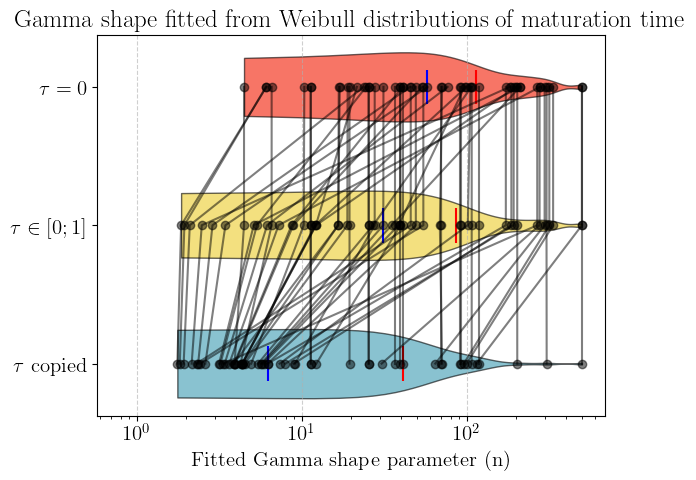

In [16]:
data0 = np.clip(gamma_pars_per_stage_copy[:,1], 0, 500)
data1 = np.clip(gamma_pars_per_stage_pos[:,1], 0, 500)
data2 = np.clip(gamma_pars_per_stage_zero[:,1], 0, 500)
data = [data0, data1, data2]

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

fig, ax = plt.subplots()
ax.set_xscale('log')
box = plt.violinplot(data, vert=False, positions=[1, 2, 3], widths=0.5, showmeans=True, showmedians=True, showextrema=False)

# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('blue')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data1[i], data2[i]], [1, 2, 3],color='black', alpha=0.5, marker='o')
    
# Aesthetic settings
plt.yticks([1, 2, 3])
ax.set_yticklabels([r'$\tau$ copied', r'$\tau \in [0;1]$',r'$\tau = 0$'])
ax.set_xlabel("Fitted Gamma shape parameter (n)")
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_log.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()



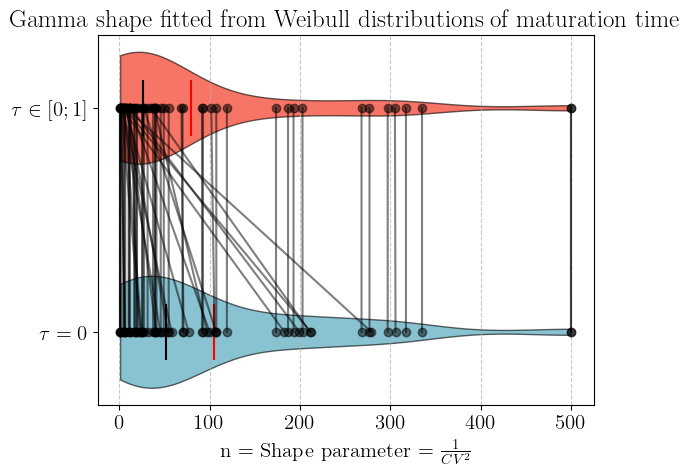

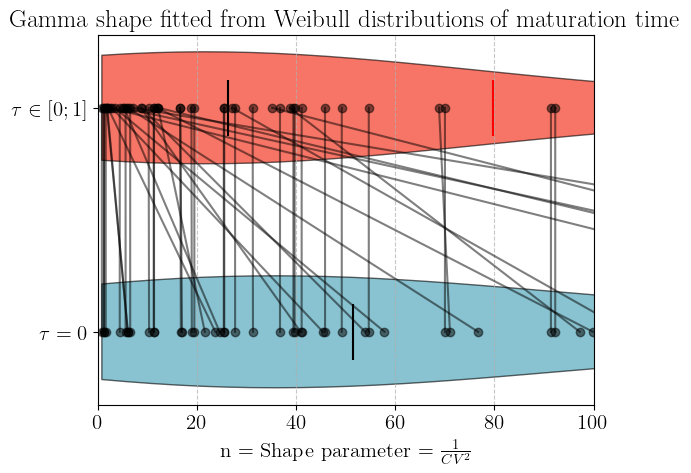

In [9]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

data0 = np.clip(gamma_pars_per_stage_zero[:,1], 0, 500)
data2 = np.clip(gamma_pars_per_stage_pos[:,1], 0, 500)
data = [data0, data2]

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

fig, ax = plt.subplots()
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=True, showextrema=False)

# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('black')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
    
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig(FIG_DIR / "n_survey__not_clipped.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()


### ZOOM ### 
# data1 = np.clip(gamma_pars_per_stage_zero[:,1], 0, 100)
# data2 = np.clip(gamma_pars_per_stage_pos[:,1], 0, 100)
# data = [data1, data2]

fig, ax = plt.subplots()
plt.xlim(0,100)
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=True, showextrema=False)
# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('black')

# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig(FIG_DIR / "n_survey_zoom.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

Text(0, 0.5, 'Gamma shape (n)')

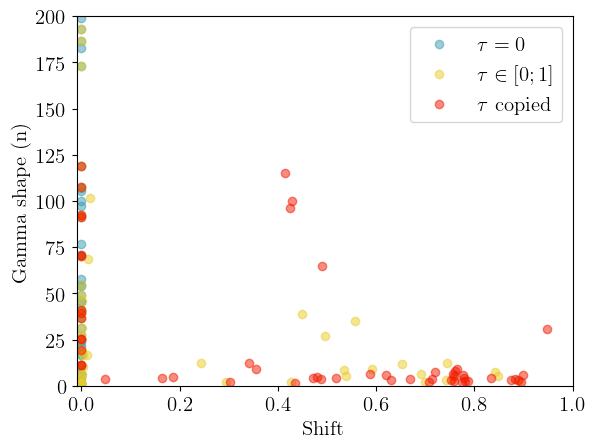

In [11]:
colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

plt.scatter(gamma_pars_per_stage_zero[:,2],gamma_pars_per_stage_zero[:,1], label = r"$\tau = 0$", alpha = .5, color = colors[2])
plt.scatter(gamma_pars_per_stage_pos[:,2],gamma_pars_per_stage_pos[:,1], label = r"$\tau \in [0;1]$", alpha = .5, color = colors[1])
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_copy[:,1], label = r"$\tau$ copied", alpha = .5, color = colors[0])
plt.xlim(-0.01,1)
plt.ylim(0,200)
plt.legend()
plt.xlabel("Shift")
plt.ylabel("Gamma shape (n)")

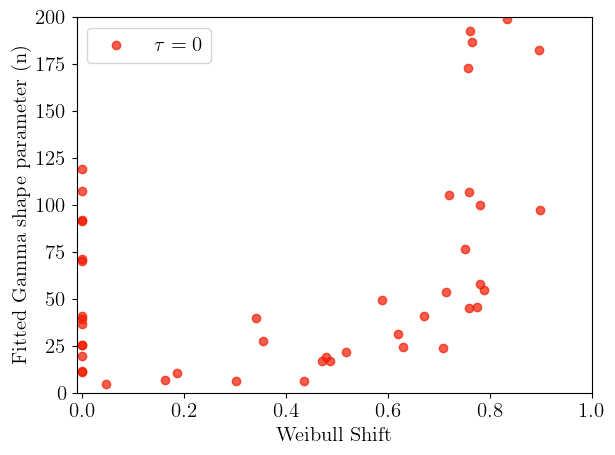

In [8]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

plt.figure()
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_zero[:,1], label = r"$\tau = 0$", alpha = .7, color = colors[2])
plt.xlim(-0.01,1)
plt.ylim(0,200)
plt.legend()
plt.xlabel("Weibull Shift")
plt.ylabel("Fitted Gamma shape parameter (n)")
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_shape_according_to_weibull-shift.pdf", bbox_inches = 'tight')
plt.show()
plt.close()

Text(0, 0.5, 'Gamma shape')

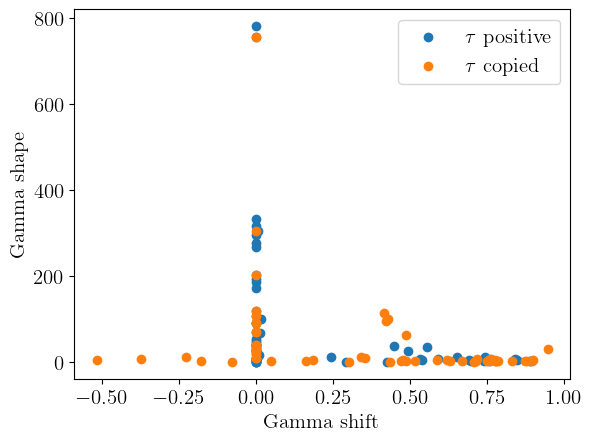

In [33]:
plt.scatter(gamma_pars_per_stage_pos[:,2],gamma_pars_per_stage_pos[:,1], label = r"$\tau$ positive")
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_copy[:,1], label = r"$\tau$ copied")
plt.legend()
plt.xlabel("Gamma shift")
plt.ylabel("Gamma shape")

### Goodness of fit 

Mean w-distance:
0.029990422651156763
0.029063908730373816
0.01959026947177153
Median w-distance:
0.013319317824732939
0.011769676589579317
0.016422492493433544


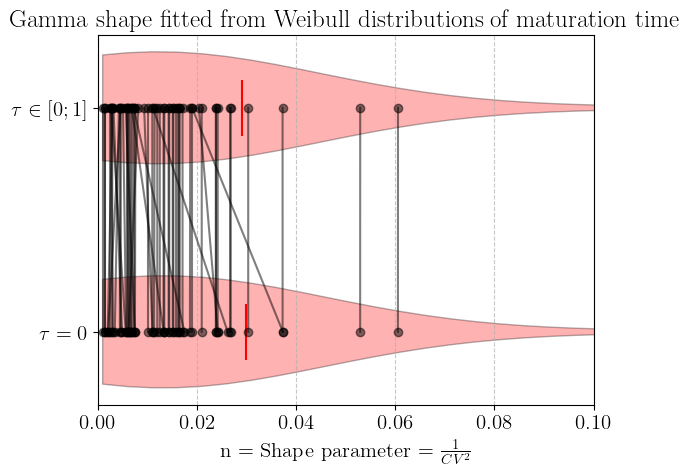

In [13]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)


print("Mean w-distance:")
print(np.mean(gamma_pars_per_stage_zero[:,3]))
print(np.mean(gamma_pars_per_stage_pos[:,3]))
print(np.mean(gamma_pars_per_stage_copy[:,3]))

print("Median w-distance:")
print(np.median(gamma_pars_per_stage_zero[:,3]))
print(np.median(gamma_pars_per_stage_pos[:,3]))
print(np.median(gamma_pars_per_stage_copy[:,3]))

data1 = np.clip(gamma_pars_per_stage_zero[:,3], 0, 500)
data2 = np.clip(gamma_pars_per_stage_pos[:,3], 0, 500)
data = [data1, data2]

fig, ax = plt.subplots()
plt.xlim(0,0.1)
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

Removing the sets of parameters with negative Weibull shifts:

Mean w-distance:
0.0135684358565061
0.012564595377832628
0.017366426541857275
Median w-distance:
0.012046213994828926
0.011039106174222367
0.015889566753916395


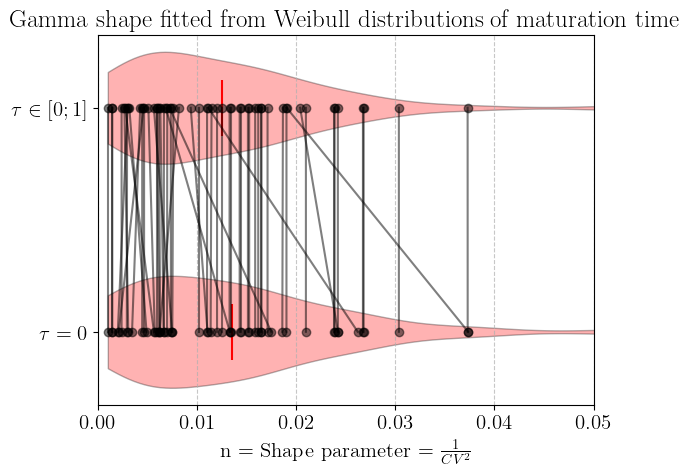

In [15]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

mask = (gamma_pars_per_stage_copy[:,2] > -1e-3) & (gamma_pars_per_stage_copy[:,2] <= 1) # Rempving negative shift outliers
gamma_pars_per_stage_zero = gamma_pars_per_stage_zero[mask]
gamma_pars_per_stage_pos = gamma_pars_per_stage_pos[mask]
gamma_pars_per_stage_copy = gamma_pars_per_stage_copy[mask]

print("Mean w-distance:")
print(np.mean(gamma_pars_per_stage_zero[:,3]))
print(np.mean(gamma_pars_per_stage_pos[:,3]))
print(np.mean(gamma_pars_per_stage_copy[:,3]))

print("Median w-distance:")
print(np.median(gamma_pars_per_stage_zero[:,3]))
print(np.median(gamma_pars_per_stage_pos[:,3]))
print(np.median(gamma_pars_per_stage_copy[:,3]))

data1 = np.clip(gamma_pars_per_stage_zero[:,3], 0, 500)
data2 = np.clip(gamma_pars_per_stage_pos[:,3], 0, 500)
data = [data1, data2]


fig, ax = plt.subplots()
plt.xlim(0,0.05)
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

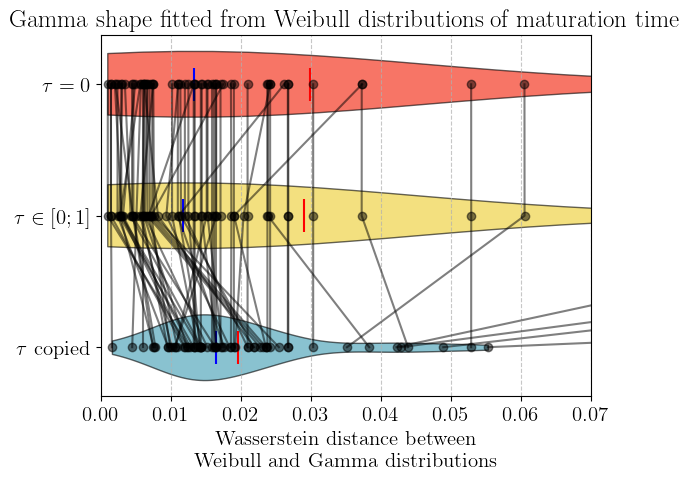

In [2]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

data0 = np.clip(gamma_pars_per_stage_copy[:,3], 0, 500)
data1 = np.clip(gamma_pars_per_stage_pos[:,3], 0, 500)
data2 = np.clip(gamma_pars_per_stage_zero[:,3], 0, 500)
data = [data0, data1, data2]

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

fig, ax = plt.subplots()
plt.xlim(0,.1)
box = plt.violinplot(data, vert=False, positions=[1, 2, 3], widths=0.5, showmeans=True, showmedians=True, showextrema=False)

# Set the color of the violin patches
for pc in box['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.6)
for pc, color in zip(box['bodies'], colors):
    pc.set_facecolor(color)
box['cmeans'].set_colors('red')
box['cmedians'].set_colors('blue')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data0[i], data1[i], data2[i]], [1, 2, 3],color='black', alpha=0.5, marker='o')
    
# Aesthetic settings
plt.yticks([1, 2, 3])
plt.xlim(0,0.07)
ax.set_yticklabels([r'$\tau$ copied', r'$\tau \in [0;1]$',r'$\tau = 0$'])
ax.set_xlabel("Wasserstein distance between \n Weibull and Gamma distributions")
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_3lines_w_dist.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

Text(0, 0.5, 'Wasserstein distance between \n Weibull and Gamma distributions')

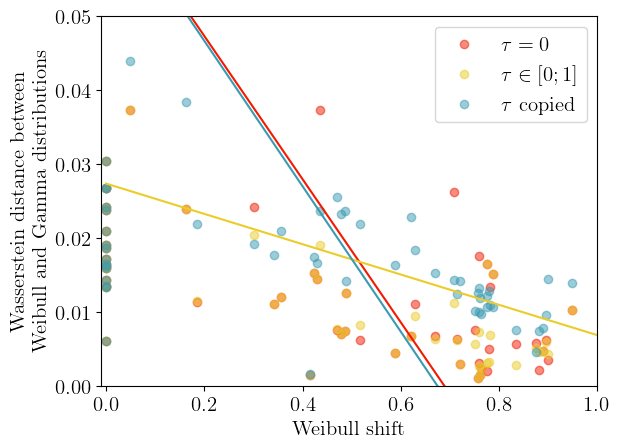

In [9]:
colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_zero[:,3], label = r"$\tau = 0$", alpha = .5, color = colors[2])
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_pos[:,3],label = r"$\tau \in [0;1]$", alpha = .5, color = colors[1])
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_copy[:,3],label = r"$\tau$ copied", alpha = .5, color = colors[0])

reg_zero = linregress(gamma_pars_per_stage_copy[:,2], gamma_pars_per_stage_zero[:,3])
reg_copy = linregress(gamma_pars_per_stage_copy[:,2], gamma_pars_per_stage_copy[:,3])
reg_pos = linregress(gamma_pars_per_stage_copy[:,2], gamma_pars_per_stage_pos[:,3])
xvect = np.linspace(0,1,50)
plt.plot(xvect, reg_zero.intercept + reg_zero.slope*xvect, color = colors[2])
plt.plot(xvect, reg_copy.intercept + reg_copy.slope*xvect, color = colors[1])
plt.plot(xvect, reg_pos.intercept + reg_pos.slope*xvect, color = colors[0])

plt.xlim(-0.01,1)
plt.ylim(0,.05)
plt.legend()
plt.xlabel("Weibull shift")
plt.ylabel("Wasserstein distance between \n Weibull and Gamma distributions")

Zero-shift regression
pvalue : 6.360202164436223e-07
slope (95%): -0.018373 +/- 0.006563
intercept (95%): 0.021586 +/- 0.003633


Positive-shift regression
pvalue : 1.5601079177572476e-09
slope (95%): -0.019955 +/- 0.005546
intercept (95%): 0.021272 +/- 0.003070


Positive-shift regression
pvalue : 1.955180618250869e-05
slope (95%): -0.014007 +/- 0.006026
intercept (95%): 0.023479 +/- 0.003335


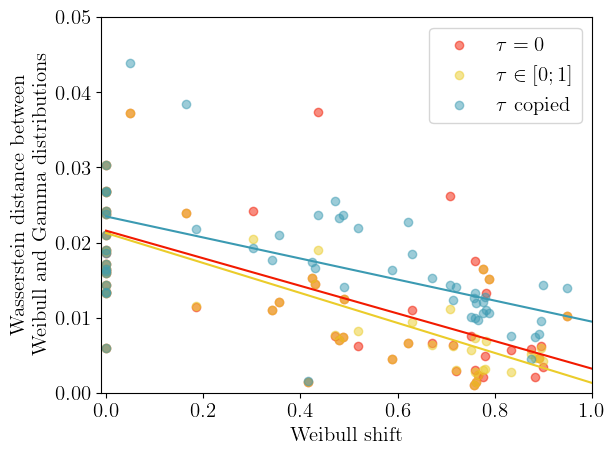

In [11]:
with open(processedDATA_DIR / "gamma_fit_per_stage_zero.npy", 'rb') as f:
    gamma_pars_per_stage_zero = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_pos.npy", 'rb') as f:
    gamma_pars_per_stage_pos = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_copy.npy", 'rb') as f:
    gamma_pars_per_stage_copy = np.load(f)

colors = [wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][0],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][2],wesanderson.color_palettes["The Life Aquatic with Steve Zissou"][0][4]]

plt.figure()
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_zero[:,3], label = r"$\tau = 0$", alpha = .5, color = colors[2])
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_pos[:,3],label = r"$\tau \in [0;1]$", alpha = .5, color = colors[1])
plt.scatter(gamma_pars_per_stage_copy[:,2],gamma_pars_per_stage_copy[:,3],label = r"$\tau$ copied", alpha = .5, color = colors[0])

mask = (gamma_pars_per_stage_copy[:,2] > -1e-3) & (gamma_pars_per_stage_copy[:,2] <= 1) 
# Ignoring fits with Weibull shift < 0 : clear outliers and very bad fits if the negative shift is not copied (ML method artefact)
reg_zero = linregress(gamma_pars_per_stage_copy[:,2][mask], gamma_pars_per_stage_zero[:,3][mask])
reg_copy = linregress(gamma_pars_per_stage_copy[:,2][mask], gamma_pars_per_stage_copy[:,3][mask])
reg_pos = linregress(gamma_pars_per_stage_copy[:,2][mask], gamma_pars_per_stage_pos[:,3][mask])
xvect = np.linspace(0,1,50)
plt.plot(xvect, reg_zero.intercept + reg_zero.slope*xvect, color = colors[2])
plt.plot(xvect, reg_pos.intercept + reg_pos.slope*xvect, color = colors[1])
plt.plot(xvect, reg_copy.intercept + reg_copy.slope*xvect, color = colors[0])


# 95% Confidence interval for zero-shift regression line
print("Zero-shift regression")
tinv = lambda p, df: abs(t.ppf(p/2, df))
ts = tinv(0.05, len(xvect)-2)
print("pvalue : " + str(reg_zero.pvalue))
print(f"slope (95%): {reg_zero.slope:.6f} +/- {ts*reg_zero.stderr:.6f}")
print(f"intercept (95%): {reg_zero.intercept:.6f}"
      f" +/- {ts*reg_zero.intercept_stderr:.6f}")

# 95% Confidence interval for positive-shift regression line
print("\n")
print("Positive-shift regression")
print("pvalue : " + str(reg_pos.pvalue))
print(f"slope (95%): {reg_pos.slope:.6f} +/- {ts*reg_pos.stderr:.6f}")
print(f"intercept (95%): {reg_pos.intercept:.6f}"
      f" +/- {ts*reg_pos.intercept_stderr:.6f}")

# 95% Confidence interval for copy-shift regression line
print("\n")
print("Positive-shift regression")
print("pvalue : " + str(reg_copy.pvalue))
print(f"slope (95%): {reg_copy.slope:.6f} +/- {ts*reg_copy.stderr:.6f}")
print(f"intercept (95%): {reg_copy.intercept:.6f}"
      f" +/- {ts*reg_copy.intercept_stderr:.6f}")
plt.xlim(-0.01,1)
plt.ylim(0,.05)
plt.legend()
plt.xlabel("Weibull shift")
plt.ylabel("Wasserstein distance between \n Weibull and Gamma distributions")
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_relation_between_wdist_and_weibullshift.pdf", bbox_inches = 'tight')
plt.show()
plt.close()

Text(0, 0.5, 'Wasserstein distance of Gamma fit $\\tau = 0$')

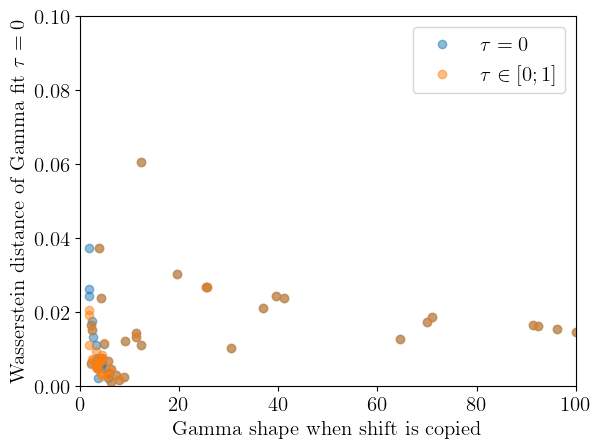

In [66]:
plt.scatter(gamma_pars_per_stage_copy[:,1],gamma_pars_per_stage_zero[:,3], label = r"$\tau = 0$", alpha = .5)
plt.scatter(gamma_pars_per_stage_copy[:,1],gamma_pars_per_stage_pos[:,3],label = r"$\tau \in [0;1]$", alpha = .5)
plt.xlim(0,100)
plt.ylim(0,.1)
plt.legend()
plt.xlabel("Gamma shape when shift is copied")
plt.ylabel(r"Wasserstein distance of Gamma fit $\tau = 0$")

# Fits multiples et répartition des paramètres shape obtenus : données whole development

## Génération des fichiers de fit et de visualisation

In [16]:
gamma_pars_whole_dev, gamma_pars_shifted_whole_dev = fit_all_weibulls(
    input_csv = "Survey_total_juvenile",
    output = "gamma_fit_whole_dev",
    raw_data_dir = rawDATA_DIR ,
    processed_data_dir = processedDATA_DIR,
    fig_dir = FIG_DIR,
    type_of_stage = "whole_dev",
    seed = 0)

Beginning non shifted analysis
(0, 10)
(1, 10)
(2, 10)
(3, 10)
(4, 10)
(5, 10)
(6, 10)
(7, 10)
(8, 10)
(9, 10)
Beginning shifted analysis
(0, 10)
(1, 10)
(2, 10)
(3, 10)
(4, 10)
(5, 10)
(6, 10)
(7, 10)
(8, 10)
(9, 10)


In [5]:
gamma_pars_whole_dev.shape[0]

10

In [2]:
with open(processedDATA_DIR / "gamma_fit_whole_dev.npy", 'rb') as f:
    gamma_pars_whole_dev = np.load(f)
with open(processedDATA_DIR / "gamma_fit_whole_dev_shifted.npy", 'rb') as f:
    gamma_pars_shifted_whole_dev = np.load(f)

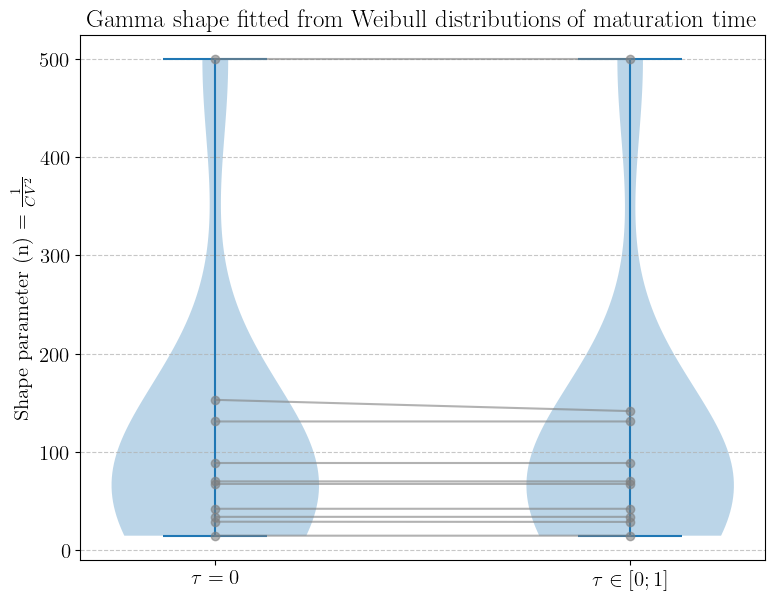

In [25]:
data1 = np.clip(gamma_pars_whole_dev[:,1], 0, 500)
data2 = np.clip(gamma_pars_shifted_whole_dev[:,1], 0, 500)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, positions=[1, 2], widths=0.5)

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([1, 2], [data1[i], data2[i]], color='gray', alpha=0.6, marker='o')

# Aesthetic settings
ax.set_xticks([1, 2])
ax.set_xticklabels([r"$\tau = 0$", r"$\tau \in [0;1]$"])
ax.set_ylabel(r'Shape parameter (n) $= \frac{1}{CV^2}$')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_whole_dev.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

## Gamma shapes fittées quand les données par stage et sur tout le développement sont disponibles

- Ips avulsus
- Cnaphalocrocis medinalis
- Amblyesius womersleyi
- Feltiella acarisuga
- Neoseiulus californicus

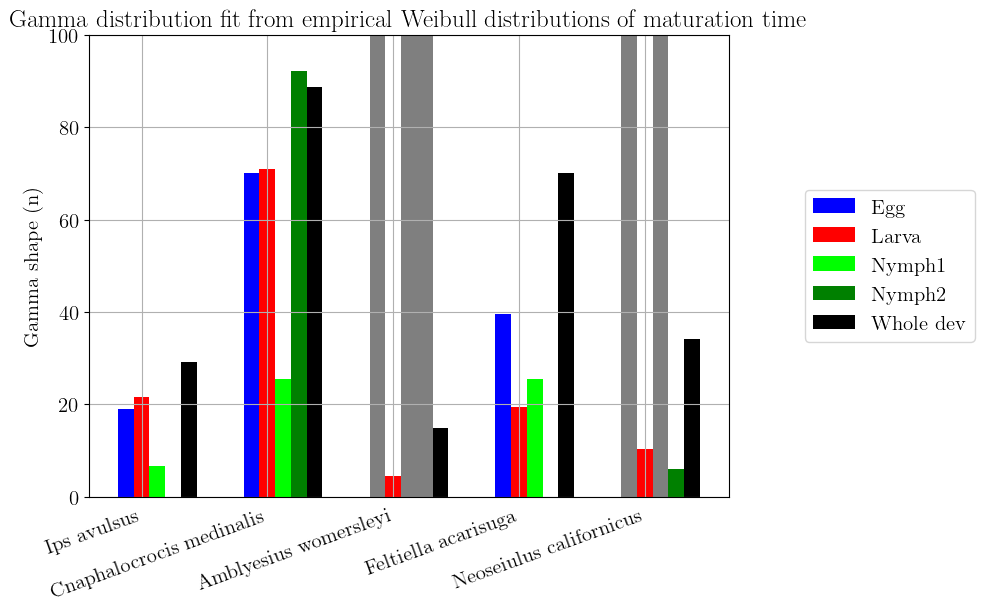

In [6]:
species = ("Ips avulsus", "Cnaphalocrocis medinalis", "Amblyesius womersleyi", "Feltiella acarisuga", "Neoseiulus californicus")
gamma_pars_dic = {
    'Egg': (19.00, 70.04, 0, 39.48, 0),
    'Larva': (21.63, 71.04, 4.47, 19.51, 10.38),
    'Nymph1': (6.58, 25.55, 0, 25.45, 0),
    'Nymph2': (0,92.27,0,0, 6.07),
    'Whole dev': (29.11, 88.74, 14.90, 70.14, 34.07)
}

gamma_pars_missing_values_dic = {
    'Egg': (0,0,100,0,100),
    'Larva': (0,0,0,0,0),
    'Nymph1': (0,0,100,0,100),
    'Nymph2': (0,0,100,0,0),
    'Whole dev': (0,0,0,0,0)
}


fig, ax = plt.subplots(layout='constrained', figsize = (9.6,6))
colors = ["blue", "red", "lime", "green", "black"]

x = 1.2*np.arange(len(species))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0
for attribute, measurement in gamma_pars_dic.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color = colors[int(multiplier)])
    # ax.bar_label(rects, padding=5)
    multiplier += 1


x = 1.2*np.arange(len(species))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0
for attribute, measurement in gamma_pars_missing_values_dic.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, color = "black", alpha = .5)
    # ax.bar_label(rects, padding=5)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Gamma shape (n)')
ax.set_xticks(x + width, species)
ax.set_ylim(0,100)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xticks(rotation=20, ha='right')
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False)
plt.grid(True)
plt.savefig(FIG_DIR / "n_survey_example_species.pdf", bbox_inches = 'tight')
ax.set_title('Gamma distribution fit from empirical Weibull distributions of maturation time')
plt.show()
plt.close()